In [1]:
from numpy import *
import matplotlib.pyplot as plt
import xarray as xr
dir='/nobackupp27/afahad/exp/'
data='/nobackupp27/afahad/project/initialization_shock/data/'

In [2]:
# RP506=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP0506/holding/geosgcm_surf/200505/*surf*200505*z.nc4')
# RP5062=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP0506/holding/geosgcm_surf/200506/*surf*200506*z.nc4')
# RP5063=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP0506/holding/geosgcm_surf/200507/*surf*200507*z.nc4')
# RP506=xr.concat([RP506,RP5062,RP5063],dim='time')
# RP506P=RP506.PRECTOT.compute()
# RP506P=RP506P*86400


In [3]:
# RP506L=RP506.SHFX.compute()

In [4]:
# ME506=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0506/holding/geosgcm_surf/200505/*surf*200505*z.nc4')
# ME5062=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0506/holding/geosgcm_surf/200506/*surf*200506*z.nc4')
# ME5063=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0506/holding/geosgcm_surf/200507/*surf*200507*z.nc4')
# ME506=xr.concat([ME506,ME5062,ME5063],dim='time')
# ME506P=ME506.PRECTOT.compute()
# ME506P=ME506P*86400

In [5]:
# ME506L=ME506.SHFX.compute()

In [7]:
# ME506s=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0506/holding/geosgcm_surf/200505/*surf*200505*z.nc4').sel(time=slice('2005-05-05','2005-05-28'))

In [ ]:
RP506P.to_netcdf('RP506P.nc4')
ME506P.to_netcdf('ME506P.nc4')

In [8]:
RP506P=xr.open_dataset('RP506P.nc4').PRECTOT.compute()
ME506P=xr.open_dataset('ME506P.nc4').PRECTOT.compute()

In [9]:
ME506=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0506/holding/geosgcm_cape/200505/*cape*200505*z.nc4').OMEGA.sel(lev=500)

ME5062=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0506/holding/geosgcm_cape/200506/*cape*200506*z.nc4').OMEGA.sel(lev=500)

RP506=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP05062/holding/geosgcm_cape/200505/*cape*200505*z.nc4').OMEGA.sel(lev=500)

RP5062=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP05062/holding/geosgcm_cape/200506/*cape*200506*z.nc4').OMEGA.sel(lev=500)

In [10]:
ME506O=xr.concat([ME506,ME5062],dim='time')
RP506O=xr.concat([RP506,RP5062],dim='time')

In [12]:
ME506O=ME506O.compute(scheduler='synchronous')
RP506O=RP506O.compute(scheduler='synchronous')

In [ ]:
# RP506L.to_netcdf('RP506L.nc4')
# ME506L.to_netcdf('ME506L.nc4')

In [13]:
RP506P=RP506P.sel(time=slice('2005-05-05','2005-06-30'))
ME506P=ME506P.sel(time=slice('2005-05-05','2005-06-30'))

In [14]:
ME506O=ME506O.resample(time='3H').mean()
RP506O=RP506O.resample(time='3H').mean()

/nobackupp27/afahad/conda/envs/earth/lib/python3.11/site-packages/xarray/core/groupby.py:668: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  index_grouper = pd.Grouper(
/nobackupp27/afahad/conda/envs/earth/lib/python3.11/site-packages/xarray/core/groupby.py:668: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  index_grouper = pd.Grouper(


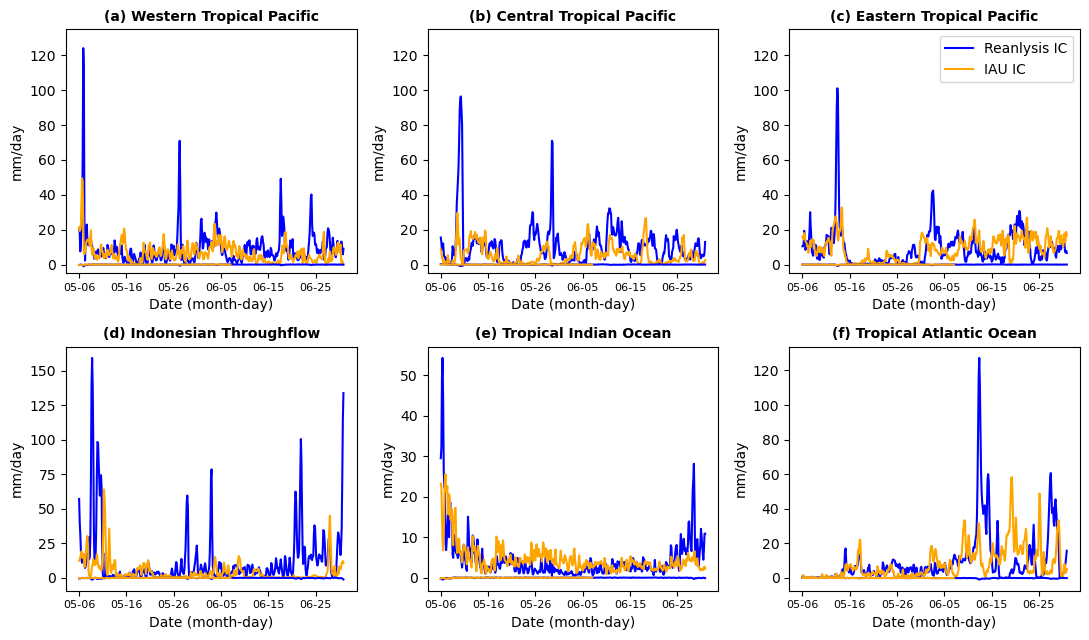

In [15]:
ticks = []

for i in range(len(ME506P.time)):
    ticks.append(str(ME506P.time.data[i])[5:10])

plt.figure(figsize=(11, 6.5))
    
x1 = 143
x2 = 143
y1 = -1
y2 = -1

plt.subplot(2, 3, 1)
plt.plot((ME506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((RP506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')

#second y axis
plt.plot((ME506O).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((RP506O).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')

plt.title('(a) Western Tropical Pacific',fontsize=10,fontweight='bold')
plt.xticks(arange(len(ticks))[::80], ticks[::80], fontsize=8)
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')
plt.ylim(-5,135)

x1 = -145
x2 = -145
y1 = 8
y2 = 8

plt.subplot(2, 3, 2)
plt.plot((ME506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((RP506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')
#second y axis
plt.plot((ME506O).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((RP506O).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')

plt.title('(b) Central Tropical Pacific',fontsize=10,fontweight='bold')
plt.xticks(arange(len(ticks))[::80], ticks[::80], fontsize=8)
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')
plt.ylim(-5,135)




x1 = -127
x2 = -127
y1 = 7
y2 = 7



plt.subplot(2, 3, 3)
plt.plot((ME506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((RP506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')
#second y axis
plt.plot((ME506O).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((RP506O).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')

plt.title('(c) Eastern Tropical Pacific',fontsize=10,fontweight='bold')
plt.xticks(arange(len(ticks))[::80], ticks[::80], fontsize=8)
plt.legend(['Reanlysis IC', 'IAU IC'])
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')
plt.ylim(-5,135)



x1 = 114
x2 = 115
y1 = 5
y2 = 6

plt.subplot(2, 3, 4)
plt.plot((ME506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((RP506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')
#second y axis
plt.plot((ME506O).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((RP506O).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')

plt.title('(d) Indonesian Throughflow',fontsize=10,fontweight='bold')
plt.xticks(arange(len(ticks))[::80], ticks[::80], fontsize=8)
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')


x1 = 89
x2 = 92
y1 = 7
y2 = 8

plt.subplot(2, 3, 5)
plt.plot((ME506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((RP506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')
#second y axis
plt.plot((ME506O).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((RP506O).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')


plt.title('(e) Tropical Indian Ocean',fontsize=10,fontweight='bold')
plt.xticks(arange(len(ticks))[::80], ticks[::80], fontsize=8)
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')


x1 = -39
x2 = -38
y1 = 7
y2 = 8

plt.subplot(2, 3, 6)
plt.plot((ME506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((RP506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')
#second y axis
plt.plot((ME506O).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((RP506O).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')

plt.title('(f) Tropical Atlantic Ocean',fontsize=10,fontweight='bold')
plt.xticks(arange(len(ticks))[::80], ticks[::80], fontsize=8)
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')

plt.tight_layout()
plt.savefig('spike_pr_omg.png',dpi=150)

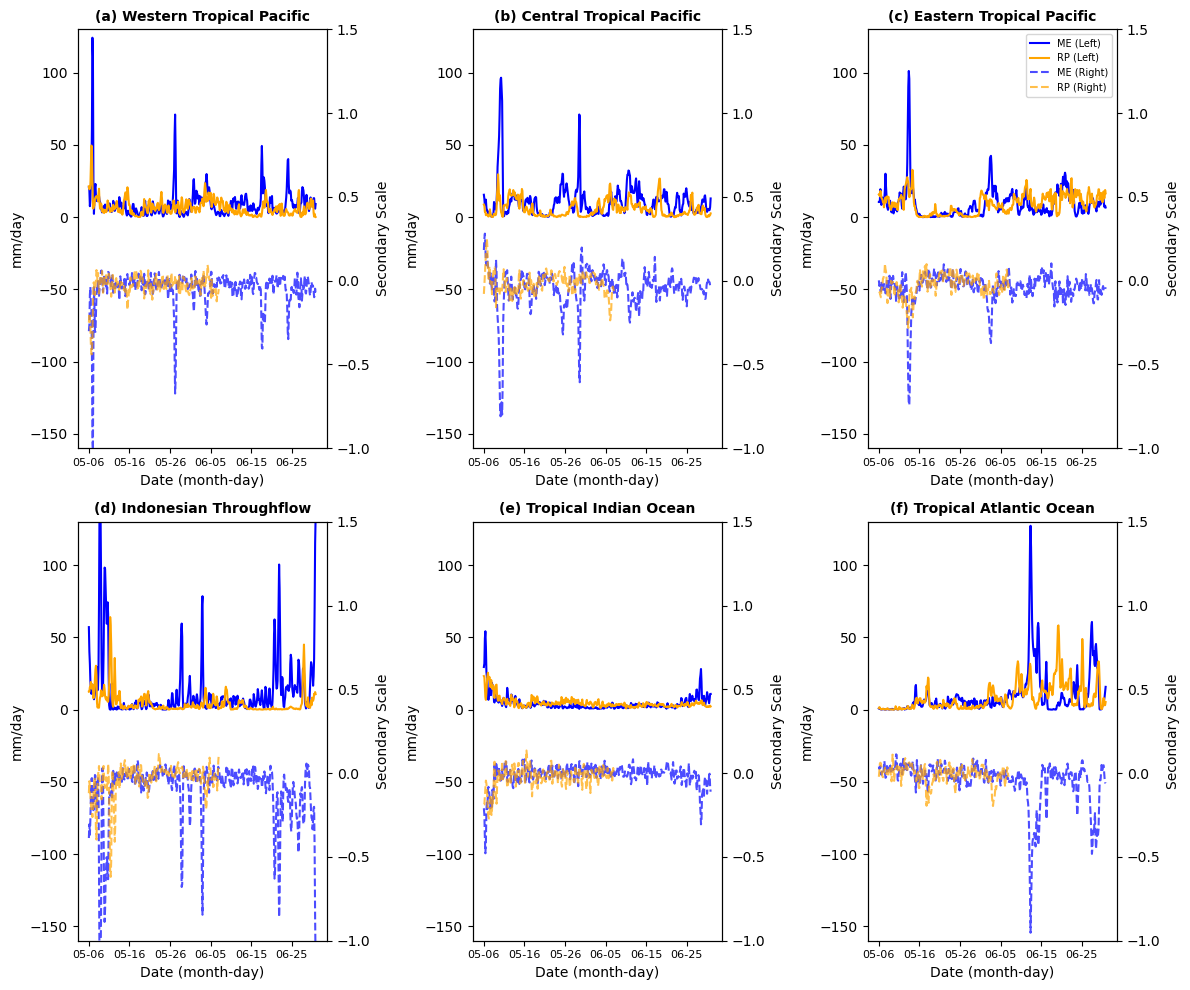

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

ticks = [str(t)[5:10] for t in ME506P.time.data]

plt.figure(figsize=(12, 10))

regions = [
    {'title': '(a) Western Tropical Pacific', 'x': (143, 143), 'y': (-1, -1)},
    {'title': '(b) Central Tropical Pacific', 'x': (-145, -145), 'y': (8, 8)},
    {'title': '(c) Eastern Tropical Pacific', 'x': (-127, -127), 'y': (7, 7)},
    {'title': '(d) Indonesian Throughflow', 'x': (114, 115), 'y': (5, 6)},
    {'title': '(e) Tropical Indian Ocean', 'x': (89, 92), 'y': (7, 8)},
    {'title': '(f) Tropical Atlantic Ocean', 'x': (-39, -38), 'y': (7, 8)},
]

for i, reg in enumerate(regions, 1):
    ax1 = plt.subplot(2, 3, i)
    
    # --- Primary Axis (Left) - 506P Data ---
    p1, = ax1.plot(ME506P.sel(lat=slice(reg['y'][0], reg['y'][1]), lon=slice(reg['x'][0], reg['x'][1])).mean(dim=['lon', 'lat']), 
                   color='blue', label='ME 506P (Left)')
    p2, = ax1.plot(RP506P.sel(lat=slice(reg['y'][0], reg['y'][1]), lon=slice(reg['x'][0], reg['x'][1])).mean(dim=['lon', 'lat']), 
                   color='orange', label='RP 506P (Left)')
    
    ax1.set_ylabel('mm/day')
    ax1.set_ylim(-160, 130)
    
    # Set ONLY positive ticks for the primary axis
    ax1.set_yticks([0, 25, 50, 75, 100, 125])
    
    # --- Secondary Axis (Right) - 506O Data ---
    ax2 = ax1.twinx()
    p3, = ax2.plot(ME506O.sel(lat=slice(reg['y'][0], reg['y'][1]), lon=slice(reg['x'][0], reg['x'][1])).mean(dim=['lon', 'lat']), 
                   color='blue', linestyle='--', alpha=0.7, label='ME 506O (Right)')
    p4, = ax2.plot(RP506O.sel(lat=slice(reg['y'][0], reg['y'][1]), lon=slice(reg['x'][0], reg['x'][1])).mean(dim=['lon', 'lat']), 
                   color='orange', linestyle='--', alpha=0.7, label='RP 506O (Right)')
    
    ax2.set_ylim(-1, 1.5)
    ax2.set_ylabel('Secondary Scale') 
    
    # Set ONLY negative ticks (and zero) for the secondary axis
    ax2.set_yticks([-1.0, -0.75, -0.5, -0.25, 0])
    
    # --- Shared Formatting ---
    ax1.set_title(reg['title'], fontsize=10, fontweight='bold')
    ax1.set_xticks(np.arange(len(ticks))[::80])
    ax1.set_xticklabels(ticks[::80], fontsize=8)
    ax1.set_xlabel('Date (month-day)')
    
    # Adjust Legend to clarify primary/secondary data
    if i == 3:
        lines = [p1, p2, p3, p4]
        ax1.legend(lines, [l.get_label() for l in lines], loc='upper right', fontsize=7)

plt.tight_layout()
plt.savefig('spike_pr_omg_filtered_ticks.png', dpi=150)
plt.show()

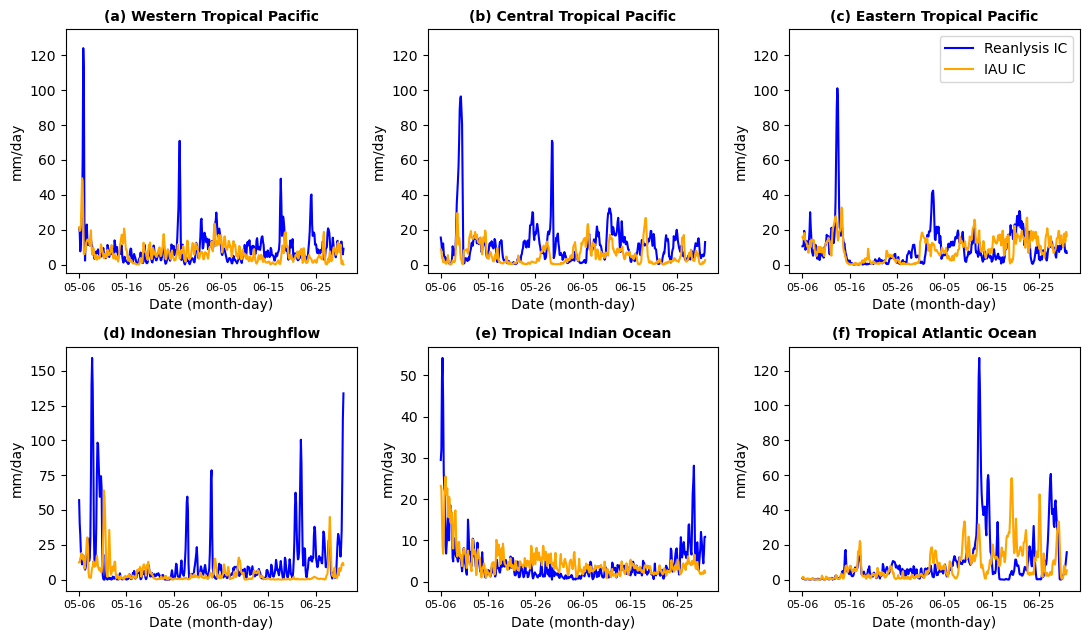

In [8]:
ticks = []

for i in range(len(ME506P.time)):
    ticks.append(str(ME506P.time.data[i])[5:10])

plt.figure(figsize=(11, 6.5))
    
x1 = 143
x2 = 143
y1 = -1
y2 = -1

plt.subplot(2, 3, 1)
plt.plot((ME506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((RP506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')

#second y axis
#plt.plot((ME506O).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
##plt.plot((RP506O).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')

plt.title('(a) Western Tropical Pacific',fontsize=10,fontweight='bold')
plt.xticks(arange(len(ticks))[::80], ticks[::80], fontsize=8)
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')
plt.ylim(-5,135)

x1 = -145
x2 = -145
y1 = 8
y2 = 8

plt.subplot(2, 3, 2)
plt.plot((ME506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((RP506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')
#second y axis
#plt.plot((ME506O).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
##plt.plot((RP506O).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')

plt.title('(b) Central Tropical Pacific',fontsize=10,fontweight='bold')
plt.xticks(arange(len(ticks))[::80], ticks[::80], fontsize=8)
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')
plt.ylim(-5,135)




x1 = -127
x2 = -127
y1 = 7
y2 = 7



plt.subplot(2, 3, 3)
plt.plot((ME506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((RP506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')
#second y axis
#plt.plot((ME506O).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
##plt.plot((RP506O).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')

plt.title('(c) Eastern Tropical Pacific',fontsize=10,fontweight='bold')
plt.xticks(arange(len(ticks))[::80], ticks[::80], fontsize=8)
plt.legend(['Reanlysis IC', 'IAU IC'])
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')
plt.ylim(-5,135)



x1 = 114
x2 = 115
y1 = 5
y2 = 6

plt.subplot(2, 3, 4)
plt.plot((ME506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((RP506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')
#second y axis
#plt.plot((ME506O).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
##plt.plot((RP506O).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')

plt.title('(d) Indonesian Throughflow',fontsize=10,fontweight='bold')
plt.xticks(arange(len(ticks))[::80], ticks[::80], fontsize=8)
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')


x1 = 89
x2 = 92
y1 = 7
y2 = 8

plt.subplot(2, 3, 5)
plt.plot((ME506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((RP506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')
#second y axis
#plt.plot((ME506O).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
##plt.plot((RP506O).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')


plt.title('(e) Tropical Indian Ocean',fontsize=10,fontweight='bold')
plt.xticks(arange(len(ticks))[::80], ticks[::80], fontsize=8)
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')


x1 = -39
x2 = -38
y1 = 7
y2 = 8

plt.subplot(2, 3, 6)
plt.plot((ME506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((RP506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')
#second y axis
#plt.plot((ME506O).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
##plt.plot((RP506O).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')

plt.title('(f) Tropical Atlantic Ocean',fontsize=10,fontweight='bold')
plt.xticks(arange(len(ticks))[::80], ticks[::80], fontsize=8)
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')

plt.tight_layout()
plt.savefig('spike_pr.png',dpi=150)

In [9]:
for j in tqdm(range(180)):
    for i in range(360):
            if nanmax(ME506P[:,j,i])>90:
                                if nanmax(RP506P[:,j,i])<60:
                                        print(ME506P.lat[j].data,ME506P.lon[i].data,j,i)

  0%|          | 0/180 [00:00<?, ?it/s]

-54.0 -31.0 36 149
-53.0 -93.0 37 87
-53.0 -92.0 37 88
-53.0 -91.0 37 89
-53.0 -90.0 37 90
-53.0 -89.0 37 91
-53.0 -88.0 37 92
-53.0 -86.0 37 94
-53.0 -85.0 37 95
-53.0 -84.0 37 96
-53.0 -83.0 37 97
-53.0 -82.0 37 98
-53.0 -81.0 37 99
-53.0 -80.0 37 100
-53.0 -79.0 37 101
-53.0 -78.0 37 102
-53.0 -77.0 37 103
-53.0 -76.0 37 104
-53.0 -75.0 37 105
-53.0 -74.0 37 106
-53.0 -73.0 37 107
-53.0 -32.0 37 148
-52.0 -97.0 38 83
-52.0 -96.0 38 84
-52.0 -95.0 38 85
-52.0 -93.0 38 87
-52.0 -92.0 38 88
-52.0 -91.0 38 89
-52.0 -76.0 38 104
-52.0 -75.0 38 105
-52.0 -74.0 38 106
-51.0 -99.0 39 81
-51.0 -98.0 39 82
-51.0 -76.0 39 104
-51.0 -75.0 39 105
-51.0 -74.0 39 106
-50.0 -139.0 40 41
-50.0 -102.0 40 78
-50.0 -101.0 40 79
-50.0 -100.0 40 80
-50.0 -76.0 40 104
-50.0 -75.0 40 105
-50.0 34.0 40 214
-49.0 -140.0 41 40
-49.0 -103.0 41 77
-49.0 -76.0 41 104
-49.0 -75.0 41 105
-49.0 39.0 41 219
-49.0 49.0 41 229
-48.0 -140.0 42 40
-48.0 -105.0 42 75
-48.0 -75.0 42 105
-48.0 -74.0 42 106
-48.0 30.0 42 21

Text(0, 0.5, 'mm/day')

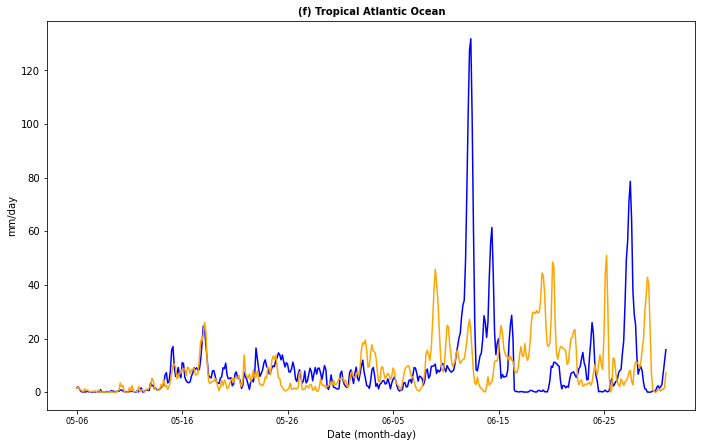

In [46]:
x1 = -39
x2 = -39
y1 = 7
y2 = 7

f()
plt.plot((ME506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((RP506P).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')
plt.title('(f) Tropical Atlantic Ocean',fontsize=10,fontweight='bold')
plt.xticks(arange(len(ticks))[::80], ticks[::80], fontsize=8)
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')

